# Multisensory Emotion Clustering

This notebook follows the workflow in `emoloop_extenstion.ipynb` for the real multisensory dataset. It:

- reads `features_real.csv`
- reverse-codes agreed negative items
- standardizes numeric features and writes `features_real_cluster_ready.csv`
- runs K-Means clustering on the standardized data
- summarizes each cluster with `performance-question`, `emotion-question`, and `emotion` buckets on a `negative` / `neutral` / `positive` scale
- prepares adapted LLM interpretation and evaluation prompts for emotions and multisensory performance


In [1]:
import json
from pathlib import Path
from statistics import median

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

In [2]:
input_path = Path("features_real.csv")
output_path = Path("features_real_cluster_ready.csv")

reverse_1_5 = [
    "The smell was distracting.",
    "The smell was annoying.",
    "Do you feel any discomfort now (e.g., nausea, vertigo, headache)? Rate it from 1 (none) to 5 (severe)",
    "Upset",
    "Irritable",
]

emotion_question_features = {
    "Interested",
    "Excited",
    "Upset",
    "Irritable",
    "Enthusiastic",
    "How did you feel during the experience?",
    "How aroused did you feel during the experience? (i.e. how activated or stimulated)",
    "How in control did you feel during the experience? (i.e. how free and autonomous vs. constrained)",
}

emotion_features = {
    "Overall feeling",
}

nine_point_features = {
    "How did you feel during the experience?",
    "How aroused did you feel during the experience? (i.e. how activated or stimulated)",
    "How in control did you feel during the experience? (i.e. how free and autonomous vs. constrained)",
}

raw_df = pd.read_csv(input_path)
raw_df.columns = [col.replace(chr(160), " ").strip() for col in raw_df.columns]
raw_df = raw_df.rename(columns={"ID": "participant_id"})
likert_1_5 = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5,
}
aligned_df = raw_df.replace(likert_1_5)

for col in reverse_1_5:
    aligned_df[col] = 6 - aligned_df[col]

feature_columns = [col for col in aligned_df.columns if col != "participant_id"]
cluster_ready_df = aligned_df.copy()
cluster_ready_df[feature_columns] = cluster_ready_df[feature_columns].apply(
    lambda col: (col - col.mean()) / col.std(ddof=0)
)
cluster_ready_df.to_csv(output_path, index=False)

profiles = aligned_df.to_dict(orient="records")
cluster_ready_df.head()

,participant_id,The smell was relevant to the images I was watching.,The smell came across strong.,The smell was distracting.,The smell was consistent with the images when released.,The smell was annoying.,The smell faded away slowly after watching the images.,The smell enhanced my viewing experience.,"Overall, I enjoyed the multisensorial experience.","Do you feel any discomfort now (e.g., nausea, vertigo, headache)? Rate it from 1 (none) to 5 (severe)",Interested,Excited,Upset,Irritable,Enthusiastic,Overall feeling,How did you feel during the experience?,How aroused did you feel during the experience? (i.e. how activated or stimulated),How in control did you feel during the experience? (i.e. how free and autonomous vs. constrained)
0,1,0.194461,0.504695,1.06341,0.504695,0.974679,-0.272772,1.426048,0.862044,0.433013,0.776151,1.259704,0.516398,0.516398,1.172604,0.974679,1.189271,1.091497,0.252745
1,2,0.194461,1.570162,-2.610189,-0.560772,-2.924038,-0.272772,-1.037126,-0.957826,-2.309401,0.776151,0.339151,0.516398,0.516398,0.159901,0.974679,0.483141,1.091497,0.252745
2,3,0.194461,0.504695,-0.773389,0.504695,0.0,-1.309307,0.194461,0.862044,0.433013,0.776151,0.339151,-1.936492,-1.936492,0.159901,0.000000,0.483141,1.091497,0.252745
3,4,-1.037126,-0.560772,0.14501,-1.626239,0.0,0.763763,-1.037126,-0.957826,0.433013,-2.173221,-2.422508,0.516398,0.516398,-2.878210,-0.974679,-1.635247,-1.319950,0.786318
4,5,-1.037126,0.504695,0.14501,-0.560772,0.0,-0.272772,-1.037126,-0.047891,0.433013,0.776151,-0.581402,0.516398,0.516398,0.159901,0.000000,-1.635247,-0.355371,-2.948694


## KMeans Result

Run direct `KMeans` clustering on the standardized questionnaire profiles, then summarize each cluster on interpretable raw-aligned scales.

### Model selection: compare $k=2,3,4,5$

Compare candidate solutions using the silhouette coefficient, Calinski--Harabasz score, Davies--Bouldin index, inertia, and cluster-size distribution. The selected value, $k=4$, is then used for cluster summarisation and the downstream LLM-as-a-judge pipeline.

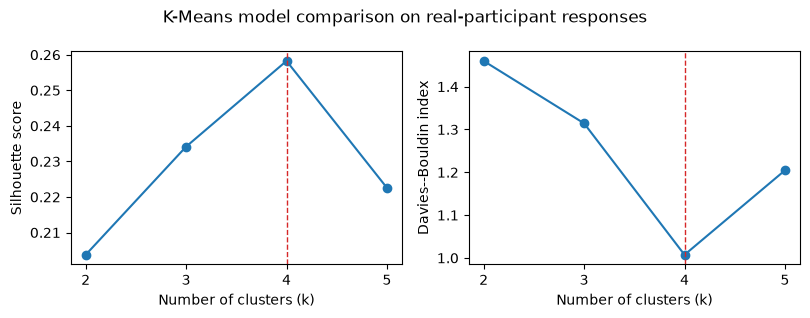

,k,silhouette,calinski_harabasz,davies_bouldin,inertia,cluster_sizes
0,2,0.203734,6.437425,1.460046,248.064793,7/12
1,3,0.234145,6.398393,1.314298,190.021208,6/9/4
2,4,0.258253,6.277184,1.007295,151.633604,9/3/5/2
3,5,0.222569,6.145880,1.204534,124.094435,4/3/5/5/2


In [3]:
candidate_vectors = cluster_ready_df[feature_columns].to_numpy(dtype=float)
k_comparison_rows = []

for candidate_k in range(2, 6):
    candidate_model = KMeans(
        n_clusters=candidate_k,
        random_state=42,
        n_init=10,
    )
    candidate_labels = candidate_model.fit_predict(candidate_vectors)
    k_comparison_rows.append({
        "k": candidate_k,
        "silhouette": silhouette_score(candidate_vectors, candidate_labels),
        "calinski_harabasz": calinski_harabasz_score(candidate_vectors, candidate_labels),
        "davies_bouldin": davies_bouldin_score(candidate_vectors, candidate_labels),
        "inertia": candidate_model.inertia_,
        "cluster_sizes": "/".join(
            str(int((candidate_labels == label).sum()))
            for label in range(candidate_k)
        ),
    })

k_comparison_df = pd.DataFrame(k_comparison_rows)
k_comparison_df.to_csv("kmeans_k_comparison.csv", index=False, float_format="%.6f")

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.2))
axes[0].plot(k_comparison_df["k"], k_comparison_df["silhouette"], marker="o")
axes[0].axvline(4, color="tab:red", linestyle="--", linewidth=1)
axes[0].set(xlabel="Number of clusters (k)", ylabel="Silhouette score")
axes[0].set_xticks(k_comparison_df["k"])

axes[1].plot(k_comparison_df["k"], k_comparison_df["davies_bouldin"], marker="o")
axes[1].axvline(4, color="tab:red", linestyle="--", linewidth=1)
axes[1].set(xlabel="Number of clusters (k)", ylabel="Davies--Bouldin index")
axes[1].set_xticks(k_comparison_df["k"])

fig.suptitle("K-Means model comparison on real-participant responses")
fig.tight_layout()
fig.savefig("../graphics/kmeans_k_comparison.pdf", bbox_inches="tight")
plt.show()

selected_k = 4
k_comparison_df

In [4]:
QUESTIONNAIRE_BUCKETS = (
    ("negative", 0),
    ("neutral", 1),
    ("positive", 2),
)
QUESTIONNAIRE_BUCKET_RANKS = {bucket_key: rank for bucket_key, rank in QUESTIONNAIRE_BUCKETS}
UNIQUE_QUESTIONNAIRE_BUCKET_KEYS = tuple(bucket_key for bucket_key, _ in QUESTIONNAIRE_BUCKETS)

def get_feature_type(feature_name: str) -> str:
    if feature_name in emotion_features:
        return "emotion"
    if feature_name in emotion_question_features:
        return "emotion-question"
    return "performance-question"

def get_feature_scale_max(feature_name: str) -> int:
    return 9 if feature_name in nine_point_features else 5

def get_questionnaire_bucket_rank(response_value: float, scale_max: int) -> int:
    if scale_max == 5:
        if response_value <= 2:
            return QUESTIONNAIRE_BUCKET_RANKS["negative"]
        if response_value <= 3:
            return QUESTIONNAIRE_BUCKET_RANKS["neutral"]
        return QUESTIONNAIRE_BUCKET_RANKS["positive"]
    if response_value <= 3:
        return QUESTIONNAIRE_BUCKET_RANKS["negative"]
    if response_value <= 6:
        return QUESTIONNAIRE_BUCKET_RANKS["neutral"]
    return QUESTIONNAIRE_BUCKET_RANKS["positive"]

def get_questionnaire_bucket_key(median_bucket_rank: float) -> str:
    clipped_rank = int(np.clip(round(median_bucket_rank), 0, max(QUESTIONNAIRE_BUCKET_RANKS.values())))
    ranked_buckets = {rank: bucket_key for bucket_key, rank in QUESTIONNAIRE_BUCKET_RANKS.items()}
    return ranked_buckets[clipped_rank]

def _build_bucket_stats_for_profiles(cluster_profiles, feature_names):
    feature_stats = {
        feature_type: {
            bucket_key: {"items": [], "value": None}
            for bucket_key in UNIQUE_QUESTIONNAIRE_BUCKET_KEYS
        }
        for feature_type in ("performance-question", "emotion-question", "emotion")
    }
    grouped_features = {feature_type: [] for feature_type in feature_stats}

    for feature_name in feature_names:
        values = [
            pd.to_numeric(profile.get(feature_name), errors="coerce")
            for profile in cluster_profiles
        ]
        values = [float(value) for value in values if pd.notna(value)]
        if not values:
            continue

        scale_max = get_feature_scale_max(feature_name)
        bucket_ranks = [get_questionnaire_bucket_rank(value, scale_max) for value in values]
        median_bucket_rank = round(float(median(bucket_ranks)), 2)
        feature_type = get_feature_type(feature_name)
        grouped_features[feature_type].append({
            "feature_name": feature_name,
            "median_bucket_rank": median_bucket_rank,
            "bucket_key": get_questionnaire_bucket_key(median_bucket_rank),
            "median_value": round(float(median(values)), 2),
            "scale_max": scale_max,
        })

    for feature_type, features in grouped_features.items():
        for bucket_key in UNIQUE_QUESTIONNAIRE_BUCKET_KEYS:
            bucket_features = [
                feature for feature in features
                if feature["bucket_key"] == bucket_key
            ]
            bucket_features.sort(key=lambda feature: (feature["median_bucket_rank"], feature["feature_name"]))
            feature_stats[feature_type][bucket_key]["items"] = [feature["feature_name"] for feature in bucket_features]
            if bucket_features:
                feature_stats[feature_type][bucket_key]["value"] = round(
                    float(np.mean([feature["median_value"] for feature in bucket_features])),
                    2,
                )
    return feature_stats

pure_kmeans_n_clusters = selected_k
pure_kmeans_vectors = cluster_ready_df[feature_columns].to_numpy(dtype=float)
pure_kmeans_model = KMeans(n_clusters=pure_kmeans_n_clusters, random_state=42, n_init=10)
pure_kmeans_labels = pure_kmeans_model.fit_predict(pure_kmeans_vectors)

pure_kmeans_clusters = []
for label in sorted(set(int(label) for label in pure_kmeans_labels)):
    member_indices = np.where(pure_kmeans_labels == label)[0].tolist()
    cluster_profiles = [profiles[index] for index in member_indices]
    buckets = _build_bucket_stats_for_profiles(cluster_profiles, feature_columns)

    dominant_emotion_bucket = next(
        (
            bucket_key
            for bucket_key in ("positive", "neutral", "negative")
            if buckets["emotion"][bucket_key]["items"]
        ),
        "unknown",
    )

    pure_kmeans_clusters.append({
        "label": label,
        "member_indices": member_indices,
        "buckets": buckets,
        "summary": f"Cluster {label} shows a {dominant_emotion_bucket} emotional profile in the multisensory experience.",
    })

pure_kmeans_clusters

[{'label': 0,
  'member_indices': [3, 4, 7, 9, 10, 11, 12, 17, 18],
  'buckets': {'performance-question': {'negative': {'items': [],
     'value': None},
    'neutral': {'items': ['The smell came across strong.',
      'The smell was consistent with the images when released.',
      'The smell was relevant to the images I was watching.'],
     'value': 3.0},
    'positive': {'items': ['Do you feel any discomfort now (e.g., nausea, vertigo, headache)? Rate it from 1 (none) to 5 (severe)',
      'Overall, I enjoyed the multisensorial experience.',
      'The smell enhanced my viewing experience.',
      'The smell faded away slowly after watching the images.',
      'The smell was annoying.',
      'The smell was distracting.'],
     'value': 4.17}},
   'emotion-question': {'negative': {'items': [], 'value': None},
    'neutral': {'items': ['Enthusiastic',
      'Excited',
      'How aroused did you feel during the experience? (i.e. how activated or stimulated)'],
     'value': 3.67},
  

In [5]:
pure_kmeans_cluster_summary_rows = []
for cluster in pure_kmeans_clusters:
    pure_kmeans_cluster_summary_rows.append({
        "cluster_label": cluster["label"],
        "cluster_size": len(cluster["member_indices"]),
        "participant_ids": [profiles[index]["participant_id"] for index in cluster["member_indices"]],
        "summary": cluster["summary"],
    })

pure_kmeans_cluster_summary_df = (
    pd.DataFrame(pure_kmeans_cluster_summary_rows)
    .sort_values("cluster_label")
    .reset_index(drop=True)
)
pure_kmeans_cluster_summary_df

,cluster_label,cluster_size,participant_ids,summary
0,0,9,"[4, 5, 8, 10, 11, 12, 13, 18, 19]",Cluster 0 shows a neutral emotional profile in...
1,1,3,"[3, 9, 16]",Cluster 1 shows a positive emotional profile i...
2,2,5,"[1, 6, 7, 14, 17]",Cluster 2 shows a positive emotional profile i...
3,3,2,"[2, 15]",Cluster 3 shows a positive emotional profile i...


In [6]:
cluster_summary_json = []
for cluster in pure_kmeans_clusters:
    cluster_summary_json.append({
        "cluster_label": cluster["label"],
        "cluster_size": len(cluster["member_indices"]),
        "buckets": cluster["buckets"],
    })

print(json.dumps(cluster_summary_json, indent=2))

[
  {
    "cluster_label": 0,
    "cluster_size": 9,
    "buckets": {
      "performance-question": {
        "negative": {
          "items": [],
          "value": null
        },
        "neutral": {
          "items": [
            "The smell came across strong.",
            "The smell was consistent with the images when released.",
            "The smell was relevant to the images I was watching."
          ],
          "value": 3.0
        },
        "positive": {
          "items": [
            "Do you feel any discomfort now (e.g., nausea, vertigo, headache)? Rate it from 1 (none) to 5 (severe)",
            "Overall, I enjoyed the multisensorial experience.",
            "The smell enhanced my viewing experience.",
            "The smell faded away slowly after watching the images.",
            "The smell was annoying.",
            "The smell was distracting."
          ],
          "value": 4.17
        }
      },
      "emotion-question": {
        "negative": {
        

## 2D PCA Visualization

Visualize the K-Means clusters in a two-dimensional PCA projection.

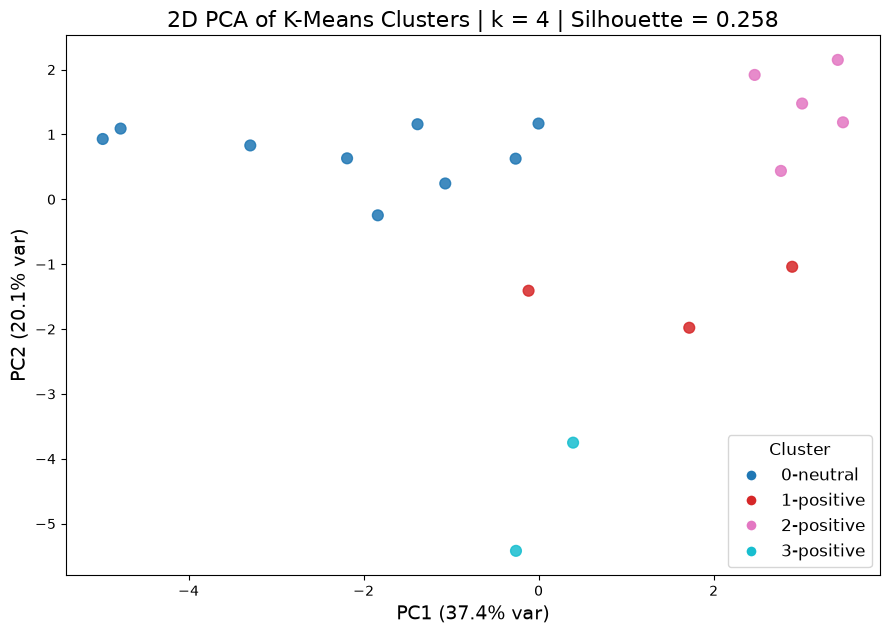

Top PC1 loadings: Excited, Overall feeling, The smell was relevant to the images I was watching.
Top PC2 loadings: The smell was distracting., The smell enhanced my viewing experience., The smell was annoying.
Saved figure to pure_kmeans_pca_2d_features_real.pdf


In [7]:
pure_kmeans_num_labels = len(set(pure_kmeans_labels))
pure_kmeans_silhouette = (
    float(silhouette_score(pure_kmeans_vectors, pure_kmeans_labels))
    if 1 < pure_kmeans_num_labels < len(pure_kmeans_vectors)
    else float("nan")
)

pca_2d = PCA(n_components=2, random_state=42)
pure_kmeans_pca = pca_2d.fit_transform(pure_kmeans_vectors)
pca_output_path = Path("pure_kmeans_pca_2d_features_real.pdf")

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    pure_kmeans_pca[:, 0],
    pure_kmeans_pca[:, 1],
    c=pure_kmeans_labels,
    cmap="tab10",
    s=60,
    alpha=0.85,
)

def top_loading_labels(component_index: int, top_n: int = 3) -> str:
    loadings = pca_2d.components_[component_index]
    top_indices = np.argsort(np.abs(loadings))[::-1][:top_n]
    return ", ".join(feature_columns[index] for index in top_indices)

def dominant_emotion_bucket_name(cluster) -> str:
    emotion_buckets = cluster["buckets"]["emotion"]
    for bucket_name in ("positive", "neutral", "negative"):
        if emotion_buckets[bucket_name]["items"]:
            return bucket_name
    return "unknown"

cluster_name_map = {
    cluster["label"]: f"{cluster['label']}-{dominant_emotion_bucket_name(cluster)}"
    for cluster in pure_kmeans_clusters
}

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}% var)", fontsize=14)
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}% var)", fontsize=14)
ax.set_title(
    f"2D PCA of K-Means Clusters | k = {pure_kmeans_n_clusters} | Silhouette = {pure_kmeans_silhouette:.3f}",
    fontsize=16,
)

unique_labels = sorted(set(int(label) for label in pure_kmeans_labels))
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=cluster_name_map.get(label, str(label)),
        markerfacecolor=scatter.cmap(scatter.norm(label)),
        markersize=8,
    )
    for label in unique_labels
]
ax.legend(handles=legend_handles, title="Cluster", loc="lower right", fontsize=12, title_fontsize=12)
plt.tight_layout(rect=(0.0, 0.08, 1.0, 1.0))
fig.savefig(pca_output_path, format="pdf", bbox_inches="tight")
plt.show()

print("Top PC1 loadings:", top_loading_labels(0))
print("Top PC2 loadings:", top_loading_labels(1))
print("Saved figure to", pca_output_path)

## LLM as a Judge

In [27]:
from openai import OpenAI

client = OpenAI()  # Reads OPENAI_API_KEY from the environment.
openai_question_embedding_cache = {}

In [28]:
interpret_prompt = f"""
You are an XR performer, emotion-focused experience designer, and multisensory performance analyst. Your goal is to interpret audience cluster results and suggest how performers can optimize a multisensory XR experience according to the audience's emotional response and perceived performance quality.

The cluster results are organized into three bucket types:

1. emotion
- This bucket captures the cluster's overall emotional state.
- It is the main signal for whether the group's overall emotional outcome is negative, neutral, or positive.
- Use items such as `Overall feeling`, `How did you feel during the experience?`, arousal, and control to understand the emotional tone.

2. emotion-question
- These are question-level emotion indicators such as interest, excitement, enthusiasm, upset, and irritability.
- Use them as supporting signals that explain the emotional profile, not as the only outcome measure.

3. performance-question
- These are multisensory performance and experience-quality signals.
- They include smell relevance, smell strength, congruence, lingering, enhancement, enjoyment, and comfort-related responses.
- Treat them as possible drivers of the emotional outcome and perceived multisensory performance.

Important interpretation rules:
- Bucket scales are `negative`, `neutral`, and `positive`.
- The raw cluster JSON is the source of truth.
- Do not invent causes that are not supported by the cluster data.
- Since discomfort, upset, irritability, distraction, and annoyance were reverse-coded before clustering, a higher aligned value indicates a better experience.

For each cluster, provide:

1. Cluster emotional profile
- Summarize the cluster's overall emotional direction.
- Mention the cluster size.
- Give the cluster a short performer-facing label.

2. What worked well
- Identify the emotional and multisensory performance signals that appear to support a stronger experience.

3. What may need improvement
- Identify negative or neutral signals that may limit emotional impact or multisensory performance quality.

4. Performer interpretation
- Explain what the cluster means for performers in plain language.
- Focus on emotional delivery, multisensory timing, congruence, comfort, stimulation, and audience engagement.

5. Optimization suggestions
- Give 3-5 practical actions performers can take.
- Suggestions may involve pacing, sensory intensity, smell timing, congruence between visual and olfactory cues, emotional expression, audience connection, or reducing overload.

6. Priority level
- Assign one priority level:
  - Maintain: already positive and worth preserving.
  - Improve: mixed or neutral and should be refined.
  - Rescue: emotionally negative or performance-limited and needs stronger redesign.

Output format:

Cluster [cluster_label]: [performer-facing label]
- Size:
- Overall emotional profile:
- What worked well:
- What needs improvement:
- Performer interpretation:
- Optimization suggestions:
  1.
  2.
  3.
- Priority level:

Use a clear, concise, performer-facing tone. Avoid statistical jargon. Do not simply restate the buckets. Explain what they mean for emotion and multisensory performance.

Cluster JSON:
{json.dumps(cluster_summary_json, indent=2)}
"""
response = client.chat.completions.create(
    model="gpt-5",
    messages=[{"role": "user", "content": interpret_prompt}]
)

print(response.choices[0].message.content)

Cluster 0: Comfortable but under-stimulated
- Size: 9
- Overall emotional profile: Neutral overall mood. People felt interested and in control, but excitement/arousal stayed muted.
- What worked well:
  - Enjoyment and “smell enhanced the experience” were strong.
  - Comfort was solid: low discomfort; smells not distracting or annoying.
  - Pleasant fade-out of scent.
- What needs improvement:
  - Smell–image alignment felt only “okay” (congruence/relevance were neutral).
  - Smell intensity read as moderate, not impactful.
  - Excitement/arousal and enthusiasm sat at neutral, matching the neutral overall feeling.
- Performer interpretation:
  - The audience was comfortable and receptive, but the sensory arc lacked lift. Smell cues were safe and non-intrusive, yet not vivid or precisely timed enough to push emotion beyond “fine.”
- Optimization suggestions:
  1. Sharpen timing with visuals so scent arrival coincides precisely with key image beats (consider slight pre-triggers or delaye

In [29]:
rubric = """
LLM-as-a-Judge Rubric for Multisensory Emotion Cluster Interpretation

You are evaluating an LLM-generated interpretation of XR audience clusters built from emotional and multisensory performance questionnaire data.

The interpretation is intended for performers who want to improve the emotional and multisensory quality of an XR experience.

The raw cluster JSON is the source of truth.

Score each criterion from 1 to 5:

1 = Poor
2 = Weak
3 = Acceptable
4 = Good
5 = Excellent

Criterion 1: Faithfulness to the raw cluster JSON
- Does the interpretation accurately reflect the cluster labels, sizes, bucket contents, and bucket directions?
- Does it avoid invented patterns or unsupported claims?

Criterion 2: Correct interpretation of the emotion bucket
- Does it correctly use the `emotion` bucket as the main indicator of whether the cluster is negative, neutral, or positive overall?
- Does it distinguish cluster-level emotional outcomes clearly?

Criterion 3: Correct use of emotion-question signals
- Does it use interest, excitement, enthusiasm, upset, and irritability appropriately as supporting emotional signals?
- Does it avoid treating them as the only emotional outcome?

Criterion 4: Correct use of performance-question signals
- Does it correctly interpret multisensory performance cues such as congruence, enhancement, enjoyment, comfort, distraction, annoyance, and sensory intensity?
- Does it treat them as possible drivers of emotional response and performance quality rather than direct proof of causation?

Criterion 5: Performer-facing usefulness
- Is the interpretation useful for performers rather than only analysts?
- Does it translate findings into practical implications for performance design and delivery?

Criterion 6: Quality of optimization suggestions
- Are the suggestions concrete, grounded in the cluster data, and relevant to emotion and multisensory performance?

Criterion 7: Priority assignment
- Is the assigned priority level (`Maintain`, `Improve`, or `Rescue`) consistent with the emotional and performance signals?

Criterion 8: Clarity and structure
- Is the output easy to follow, well structured, and concise?

Overall quality level:
- Excellent: 36-40
- Good: 30-35
- Acceptable: 24-29
- Weak: 16-23
- Poor: 8-15
"""

In [30]:
eval_prompt = f"""
You are an expert LLM-as-a-Judge evaluating an LLM-generated interpretation of XR audience clusters built from emotion and multisensory performance questionnaire data.

The interpretation was generated for performers who want to optimize an XR multisensory experience.

You will receive three inputs:

Input 1: Raw cluster JSON
- cluster_label
- cluster_size
- buckets for `performance-question`, `emotion-question`, and `emotion`
- negative / neutral / positive bucket values and item names

Input 2: LLM-generated interpretation
- the interpretation to evaluate

Input 3: Rubric
- the evaluation criteria and scoring scale

Evaluation principles:
- Treat the raw cluster JSON as the source of truth.
- Use the `emotion` bucket as the main indicator of overall emotional outcome.
- Use `emotion-question` and `performance-question` buckets as supporting evidence.
- Do not reward unsupported causal claims.
- Reward suggestions that are actionable for emotional delivery and multisensory performance design.

Evaluation output format:

Criterion scores:
1. Faithfulness to the raw cluster JSON: [score]/5
2. Correct interpretation of the emotion bucket: [score]/5
3. Correct use of emotion-question signals: [score]/5
4. Correct use of performance-question signals: [score]/5
5. Performer-facing usefulness: [score]/5
6. Quality of optimization suggestions: [score]/5
7. Priority assignment: [score]/5
8. Clarity and structure: [score]/5

Total score: [score]/40

Overall quality level:
[Excellent / Good / Acceptable / Weak / Poor]

Evidence-based assessment:
- Correct claims:
- Incorrect or unsupported claims:
- Missing important points:

Main strengths:
-

Main weaknesses:
-

Suggested revisions:
-

Final judgement:
[Briefly state whether the interpretation is suitable for performer-facing multisensory XR optimization.]

Input 1: Raw cluster JSON
{json.dumps(cluster_summary_json, indent=2)}

Input 2: Prompt for LLM-generated interpretation
{interpret_prompt}

Input 3: LLM-generated interpretation
{response.choices[0].message.content}

Input 4: Rubric
{rubric}
"""
eval_response = client.chat.completions.create(
    model="gpt-5.6-sol",
    messages=[{"role": "user", "content": eval_prompt}]
)

print(eval_response.choices[0].message.content)

Criterion scores:
1. Faithfulness to the raw cluster JSON: 4/5
2. Correct interpretation of the emotion bucket: 5/5
3. Correct use of emotion-question signals: 5/5
4. Correct use of performance-question signals: 4/5
5. Performer-facing usefulness: 5/5
6. Quality of optimization suggestions: 5/5
7. Priority assignment: 5/5
8. Clarity and structure: 5/5

Total score: 38/40

Overall quality level:
Excellent

Evidence-based assessment:
- Correct claims:
  - Cluster sizes, labels, and overall emotional directions are accurately reported.
  - Cluster 0 is correctly characterized as emotionally neutral despite several positive supporting signals. Its neutral excitement, enthusiasm, arousal, scent strength, congruence, and relevance are appropriately identified as improvement areas.
  - Cluster 1 is correctly described as positive overall, with positive enjoyment, enhancement, congruence, relevance, comfort, and reverse-coded annoyance/distraction responses.
  - Cluster 1’s negative slow-fade 